#**Laboratorio di Introduzione alla Matematica Computazionale - Esercizi in Julia**

##**Esercitazione 5: Interpolazione e fit di dati**

Le tecniche di interpolazione o *data fitting* si usano per risolvere problemi come il seguente.

Supponiamo di aver fissato dei *nodi di interpolazione*, cioè punti $\{x_i\}_{i=0,\dots ,n}$, con $x_{i}<x_{i+1}$, in un intervallo $[a,b]$ della retta reale, e di conoscere i valori $y_{i}=f(x_i)$ di una certa funzione $f$ (non nota) in corrispondenza dei nodi. Vogliamo approssimare i valori di $f$ in altri punti di $[a,b]$, i cosiddetti *query points*.

L'idea è di determinare una funzione $g$ che imiti $f$ in modo ``plausibile'' e in particolare assuma i valori prescritti sugli $x_i$, in modo esatto (interpolazione) o approssimato (fit). Una volta determinata $g$, la si valuta nei query points.

Per eseguire l'interpolazione in Julia useremo la libreria `Interpolations.jl`. Vediamo alcuni casi interessanti.

---
# Setup iniziale
Carichiamo le librerie necessarie.

In [1]:
import Pkg; Pkg.add("Interpolations")

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
   Installed Xorg_libpciaccess_jll ─ v0.18.1+0
   Installed libva_jll ───────────── v2.23.0+0
   Installed libdrm_jll ──────────── v2.4.125+1
    Updating `~/.julia/environments/v1.11/Project.toml`
  [a98d9a8b] + Interpolations v0.16.2
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [a65dc6b1] + Xorg_libpciaccess_jll v0.18.1+0
  [8e53e030] + libdrm_jll v2.4.125+1
  [9a156e7d] + libva_jll v2.23.0+0
Precompiling project...
   1701.4 ms  ✓ Xorg_libpciaccess_jll
    546.6 ms  ✓ libdrm_jll
    735.7 ms  ✓ libva_jll
  3 dependencies successfully precompiled in 13 seconds. 468 already precompiled.


In [2]:
import Pkg; Pkg.add("Polynomials")

   Resolving package versions...
   Installed Polynomials ─ v4.1.1
    Updating `~/.julia/environments/v1.11/Project.toml`
  [f27b6e38] + Polynomials v4.1.1
    Updating `~/.julia/environments/v1.11/Manifest.toml`
  [f27b6e38] + Polynomials v4.1.1
Precompiling project...
  30460.5 ms  ✓ Polynomials
   1898.9 ms  ✓ Polynomials → PolynomialsChainRulesCoreExt
   2085.3 ms  ✓ Polynomials → PolynomialsRecipesBaseExt
   2241.4 ms  ✓ Polynomials → PolynomialsFFTWExt
  10265.7 ms  ✓ Polynomials → PolynomialsMakieExt
  5 dependencies successfully precompiled in 43 seconds. 471 already precompiled.


In [ ]:
import Pkg; Pkg.add("CubicSplines")

In [15]:
using Plots
using Interpolations
using CubicSplines
using Polynomials

---
# 1. Interpolazione


La tecnica di interpolazione più semplice è l'*interpolazione lineare*: prendiamo $g$ come la funzione lineare a tratti che collega i punti $(x_i,y_i).$

Per esempio, consideriamo la funzione $f(x)=1/(1+x^2)$ definita su $[-5,5]$ e supponiamo di conoscere i valori di $f$ nei nodi $x_i=5\cos(\frac{i\pi}{10})$ per $i=0,\ldots, 10$. Costruiamo l'esempio in Julia e disegnamo i punti da interpolare:

```julia
# Definiamo la funzione da interpolare
f(t) = 1 / (1 + t^2)

# Definiamo i nodi di interpolazione
n = 11
x = 5 .* cos.(range(0, stop=pi, length=n))
y = f.(x)

# Raffiguriamo i nodi
scatter(x, y, label="Punti noti", marker=:circle)
```

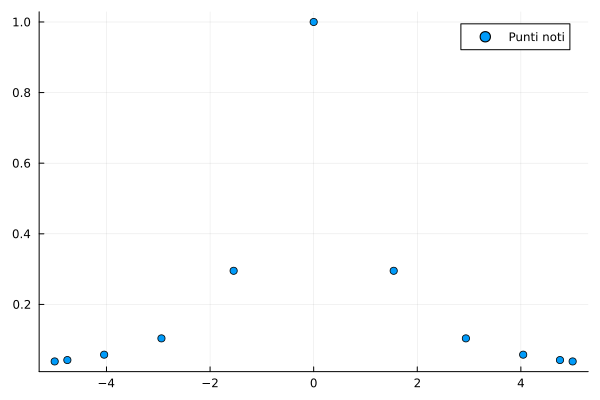

In [4]:
# Definiamo la funzione da interpolare
f(t) = 1 / (1 + t^2)

# Define i nodi di interpolazione
n = 11
x = 5 .* cos.(range(0, stop=pi, length=n))
y = f.(x)

# Raffiguriamo i nodi
scatter(x, y, label="Punti noti", marker=:circle)

Ora cerchiamo un'approssimazione di $f$ in 100 punti equispaziati sull'intervallo $[-5,5]$, usando l'interpolazione lineare:

```julia
# 100 query points
interpx = range(-5, stop=5, length=100)

# Interpolazione lineare
# Nota: Interpolations.jl richiede nodi ordinati
p = sortperm(x)
nodes_x = x[p]
nodes_y = y[p]

itp_linear = LinearInterpolation(nodes_x, nodes_y)
interpy_lin = itp_linear.(interpx)

# Raffiguriamo i risultati
plot(interpx, interpy_lin, label="lineare", color=:red)
scatter!(x, y, label="nodi", mc=:blue)
```

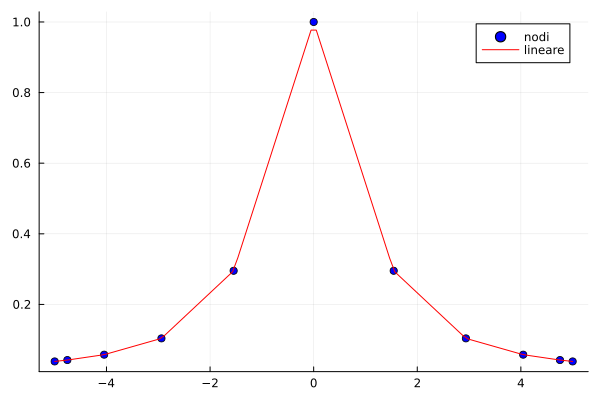

In [5]:
# 100 query points
interpx = range(-5, stop=5, length=100)

# Interpolazione lineare
# Nota: Interpolations.jl richiede nodi ordinati
p = sortperm(x)
nodes_x = x[p]
nodes_y = y[p]

itp_linear = LinearInterpolation(nodes_x, nodes_y)
interpy_lin = itp_linear.(interpx)

# Raffiguriamo i risultati
scatter(x, y, label="nodi", mc=:blue)
plot!(interpx, interpy_lin, label="lineare", color=:red)
# plot!(interpx, f.(interpx), label="esatta", color=:black, lw=2)

Un tipo di interpolazione molto diffuso è l'interpolazione con *spline cubiche*. In questo caso $g$ viene scelta come una funzione polinomiale a tratti, con polinomi di grado al più 3, e raccordi $C^2$ nei nodi. Proviamo ad applicare questo tipo di interpolazione al nostro esempio.

```julia
spline = CubicSpline(nodes_x, nodes_y)
interpy_cubic = spline[interpx]
```

In [20]:
spline = CubicSpline(nodes_x, nodes_y)
interpy_cubic = spline[interpx]

100-element Vector{Float64}:
 0.038461538461538464
 0.03994002715905505
 0.04161947778192573
 0.043382027820545545
 0.04531985534275136
 0.047413917545035676
 0.04962429742447483
 0.05191107797814513
 0.05423434220312296
 0.056554173096484625
 0.05892880417018173
 0.06179898579544116
 0.06516543851071567
 ⋮
 0.06179898579544117
 0.058928804170181745
 0.05655417309648463
 0.05423434220312296
 0.05191107797814513
 0.04962429742447483
 0.047413917545035676
 0.045319855342751354
 0.043382027820545545
 0.04161947778192573
 0.03994002715905505
 0.038461538461538464

Possiamo raffigurare tutti i risultati, aggiungendo anche al grafico i valori esatti della funzione.

```julia
# Raffiguriamo i risultati
scatter(x, y, label="nodi", mc=:blue)
plot!(interpx, interpy_lin, label="lineare", color=:red)
plot!(interpx, interpy_cubic, label="cubica", color=:green)
plot!(interpx, f.(interpx), label="esatta", color=:black, lw=2)
```

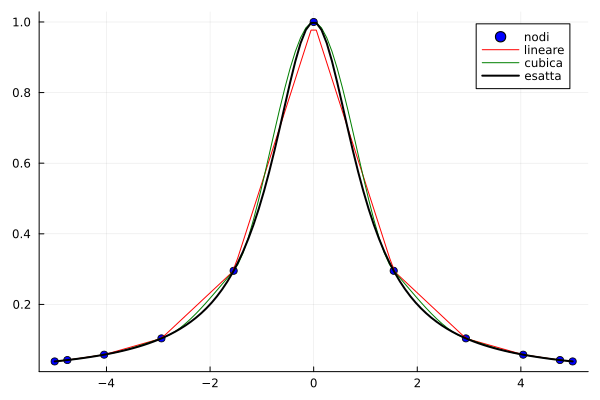

In [19]:
# Raffiguriamo i risultati
scatter(x, y, label="nodi", mc=:blue)
plot!(interpx, interpy_lin, label="lineare", color=:red)
plot!(interpx, interpy_cubic, label="cubica", color=:green)
plot!(interpx, f.(interpx), label="esatta", color=:black, lw=2)

Un'altra tecnica per interpolare $n+1$ punti dati $(x_i,y_i)$ consiste nella scelta di $g$ come l'unico polinomio di grado $\leq n$ che assume i valori prescritti $y_i$ nei nodi $x_i$ (*interpolazione polinomiale*). Un modo conveniente per esprimere il polinomio interpolatore è dato dai *polinomi di Lagrange*.

Ricordiamo che i polinomi di Lagrange rispetto ai nodi $x_0,\ldots,x_n$ sono definiti come

$$
L_i(x)=\prod_{j=0,\ldots,n; j\neq i}\frac{x-x_j}{x_i-x_j},\qquad i=0,\ldots,n
$$

e formano una base dello spazio dei polinomi di grado al più $n$.

Si dimostra che il polinomio di interpolazione $p(x)$ si può scrivere nella base di Lagrange come
$$
p(x)=\sum_{i=0}^n y_i L_i(x).
$$


**Esercizio 1**. Scrivere una function `lagrange(x,y,interpx)` che prenda in ingresso
* il vettore `x` di lunghezza $n$ contenente i nodi di interpolazione;
* il vettore `y` di lunghezza $n$ contenente i valori da interpolare in corrispondenza dei nodi,
* il vettore `interpx` di lunghezza $m$ contenente i punti sui quali vogliamo valutare il polinomio interpolatore,

e restituisca in output il vettore `v` di lunghezza $m$ contenente i valori del polinomio interpolatore sui punti di `interpx`.

Suggerimento: valutate direttamente i polinomi di Lagrange su `interpx`, senza determinare il polinomio interpolatore in base monomiale.

In [22]:
function lagrange(x, y, interpx)
    n = length(x)
    m = length(interpx)
    v = zeros(m)

    for k in 1:m
        val = 0.0
        for i in 1:n
            # Calcolare la base di polinomi di Lagrange L_i(x)
            L = 1.0
            for j in 1:n
                if i != j
                    L *= (interpx[k] - x[j]) / (x[i] - x[j])
                end
            end
            val += y[i] * L
        end
        v[k] = val
    end
    return v
end

lagrange (generic function with 1 method)

**Esercizio 2**. Si usi la function `lagrange` appena definita per risolvere il problema dell'interpolazione per la funzione $f(x)=1/(1+x^2)$ su $[-5,5]$ sui punti $x_i=5\cos(\frac{i\pi}{10})$, $i=0,\ldots,10$ visti prima; si mostri l'errore di interpolazione disegnando la funzione e il polinomio interpolatore come nel grafico precedente.

Suggerimento: come *query points* prendere 100 punti linearmente equispaziati nell'intervallo $[-5,5]$.

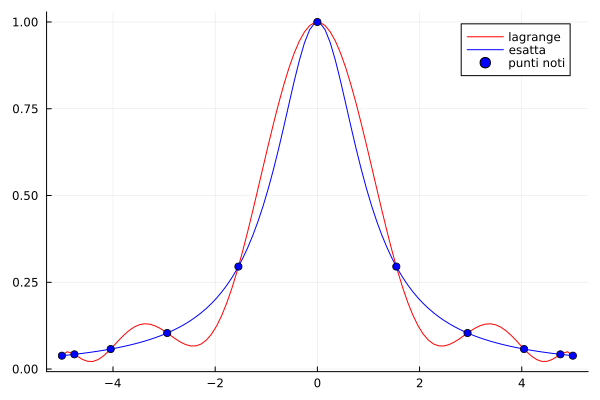

In [ ]:
f(t) = 1 / (1 + t^2)
n = 11
# Si generino ancora i nodi (non necessario se ancora in memoria)
x = 5 .* cos.(range(0, stop=pi, length=n))
y = f.(x)

m = 100
interpx = range(-5, 5, length=m)

v = lagrange(x, y, interpx)
yesatta = f.(interpx)

# Raffiguriamo i risultati
p1 = plot(interpx, v, color=:red, label="lagrange")
plot!(p1, interpx, yesatta, color=:blue, label="esatta")
scatter!(p1, x, y, color=:blue, markershape=:circle, label="punti noti")
display(p1)

**Esercizio 3**. Sempre per la funzione $f(x)=1/(1+x^2)$ definita su $[-5,5]$, eseguite e disegnate delle interpolazioni polinomiali di grado crescente, su nodi equispaziati. Che cosa osservate? L'approssimazione migliora al crescere del grado?

Iteriamo sul numero di nodi...


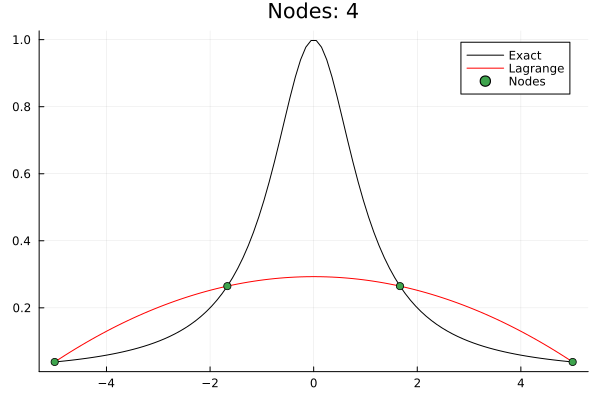

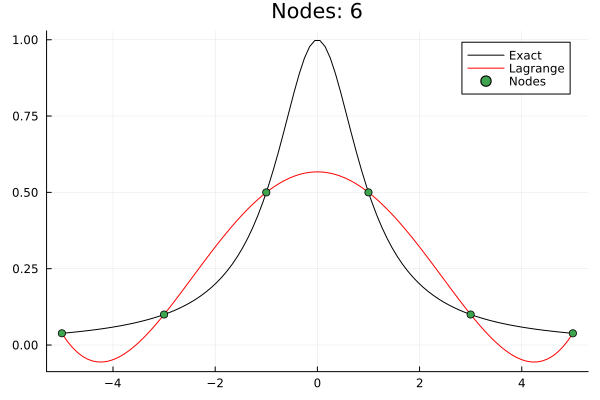

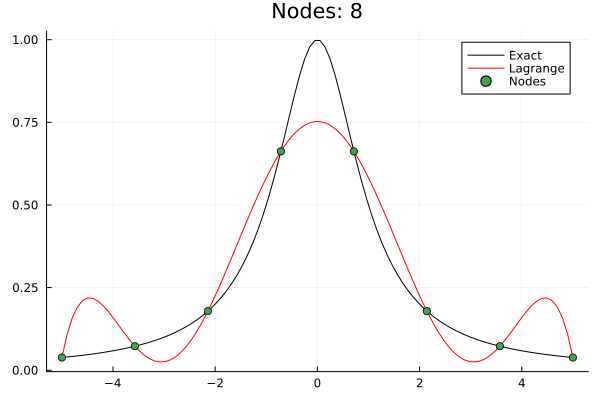

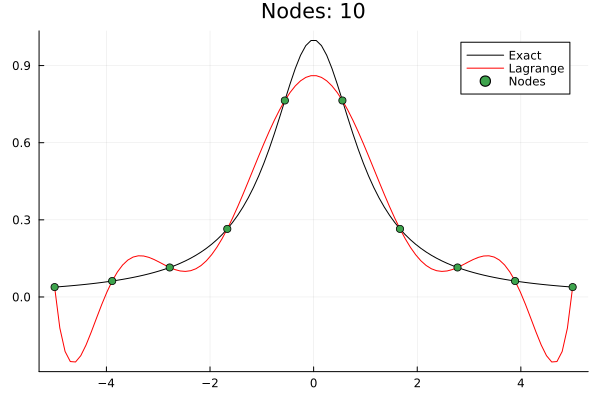

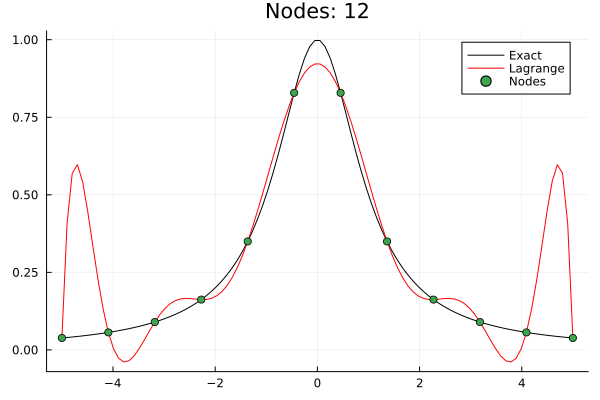

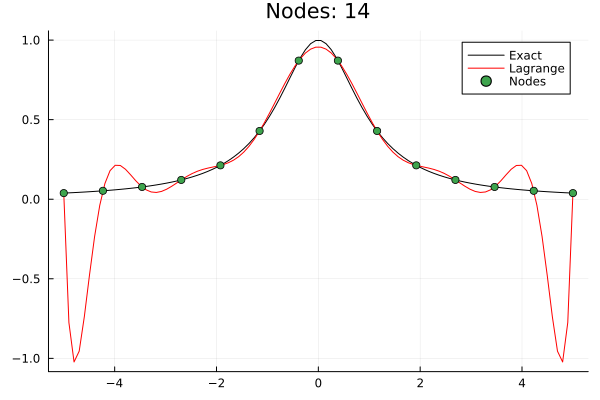

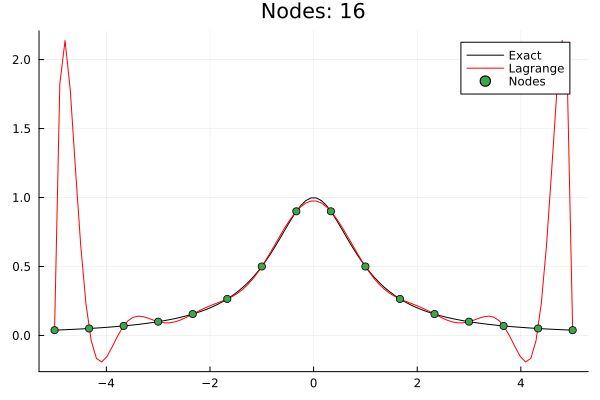

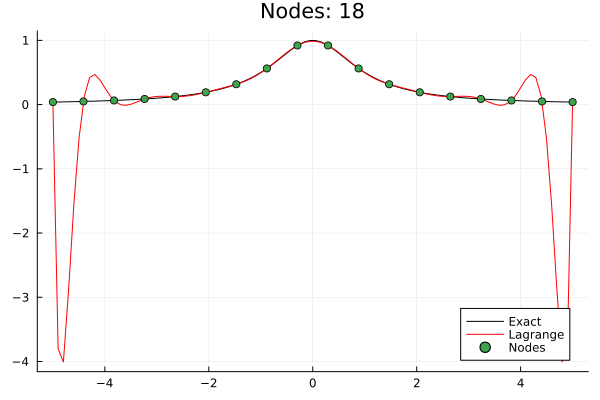

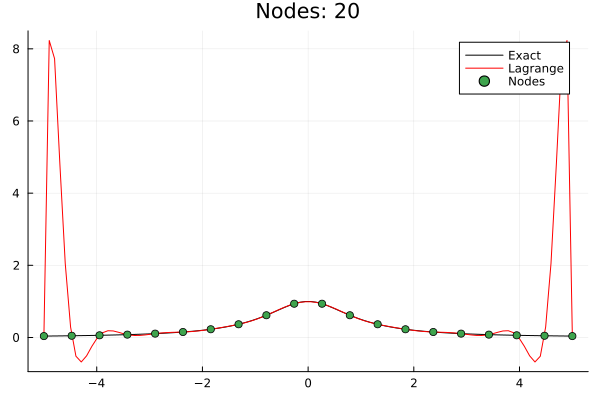

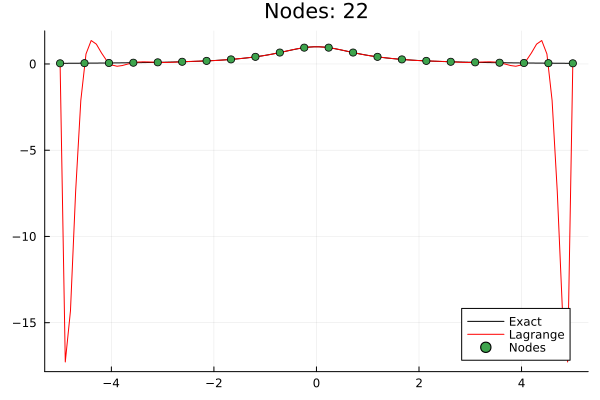

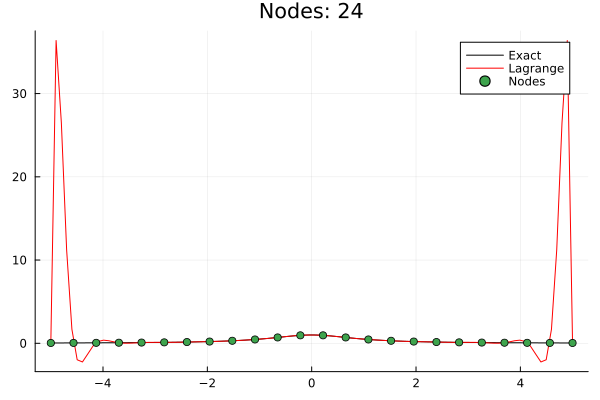

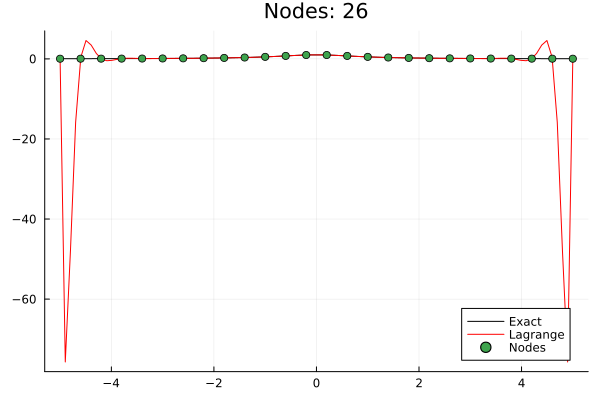

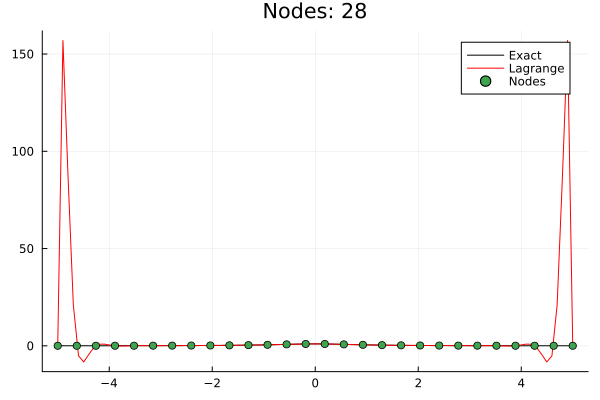

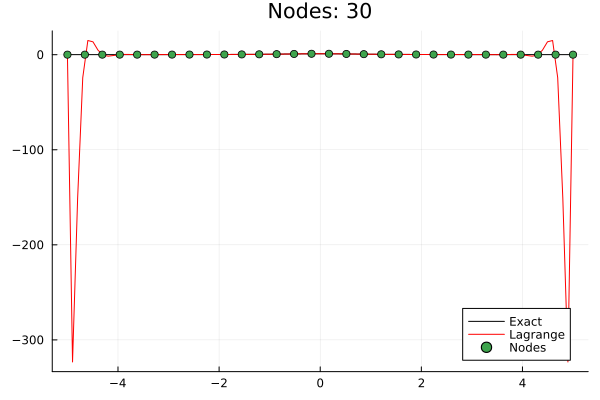

In [ ]:
println("Iteriamo sul numero di nodi...")
for n_nodes in 4:2:30
    # Generiamo nodi equispaziati
    local_x = range(-5, 5, length=n_nodes)
    local_y = f.(local_x)

    # Valutiamo l'interpolante sui query points
    v_dynamic = lagrange(local_x, local_y, interpx)

    # Raffiguriamo i risultati
    p_dyn = plot(interpx, f.(interpx), color=:black, label="Exact", title="Nodi: $n_nodes")
    plot!(p_dyn, interpx, v_dynamic, color=:red, label="Lagrange")
    scatter!(p_dyn, local_x, local_y, label="Nodi")

    display(p_dyn)
    sleep(0.5) # Equivalente a pause in MATLAB
end

---
# 2. Fit di dati


Dati i punti $(x_i,y_i)$, $i=1,\ldots,m$ e un intero positivo $n<m$, il problema del fit polinomiale consiste nel determinare un polinomio $p(x)$ di grado $n$ tale che $p(x_i)\approx y_i$ nel senso dei minimi quadrati, cio\`e in modo da minimizzare la quantità
$$
(p(x_1)-y_1)^2+(p(x_2)-y_2)^2+\dots +(p(x_m)-y_m)^2.
$$
In Julia il calcolo dei coefficienti di $p(x)$ si pu\`o effettuare con il comando

```julia
fit(x,y,n)
```

dove `x` è il vettore degli $x_i$ e
`y`, il vettore degli $y_i$ ed `n` è il grado del polinomio.

**Esercizio 4**. Si consideri la funzione $f(x)=1/(x+(1-x)^2)$ sull'intervallo $[-2,2]$. Si valuti $f(x)$ in 20 punti equispaziati $x_i$, $i=1,\ldots, 20$, sull'intervallo $[-2,2]$ e si calcolino i coefficienti del polinomio $p(x)$ di grado 3 tale che $p(x_i)\approx f(x_i)$ nel senso dei minimi quadrati. Si tracci nella stessa figura il grafico di $f(x)$ e quello di $p(x)$. Si ripeta poi l'operazione per $n=5,8,10,17$, sempre nella stessa figura. Come si comporta la qualità di approssimazione della funzione all'aumentare del grado del polinomio?

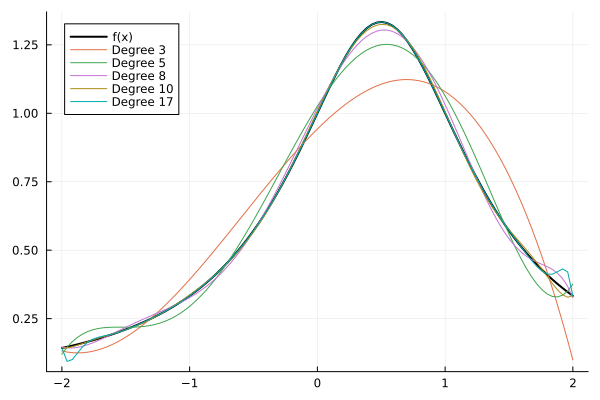

In [31]:
f(x) = 1 / (x + (1 - x)^2)
xi = range(-2, stop=2, length=20)
yi = f.(xi)

# Raffiguriamo la funzione esatta
fig = plot(range(-2, 2, length=100), f.(range(-2, 2, length=100)), label="f(x)", lw=2, color=:black)
#display(fig)

interpx = range(-2, stop=2, length=100)
degrees = [3, 5, 8, 10, 17]
for d in degrees
    p_fit = fit(xi, yi, d)
    plot!(fig, interpx, p_fit.(interpx), label="Degree " * string(d))
    #display(fig)
end

display(fig)

**Esercizio 5**. Come nell'esercizio precedente, sia $f(x)=1/(x+(1-x)^2)$ definita sull'intervallo $[-2,2]$, e siano gli $x_i$ definiti come sopra. Consideriamo 100 punti $z_1,\ldots,z_{100}$ equidistanziati nell'intervallo. Per le approssimazioni seguenti, valutare gli errori di approssimazione sugli $z_i$ e tracciarne il grafico:
\begin{itemize}
\item
{\tt polyfit} con $n=5$,
\item
{\tt interp1} con opzioni lineare e spline,
\item interpolazione polinomiale con la function
{\tt lagrange} dell'Esercizio 2.
\end{itemize}


┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


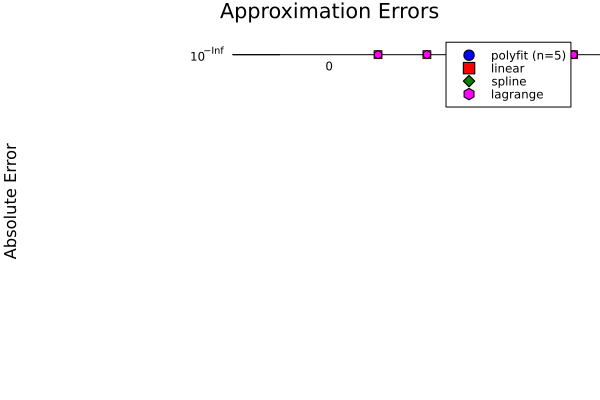

┌ Warning: No strict ticks found
└ @ PlotUtils ~/.julia/packages/PlotUtils/HX80C/src/ticks.jl:194


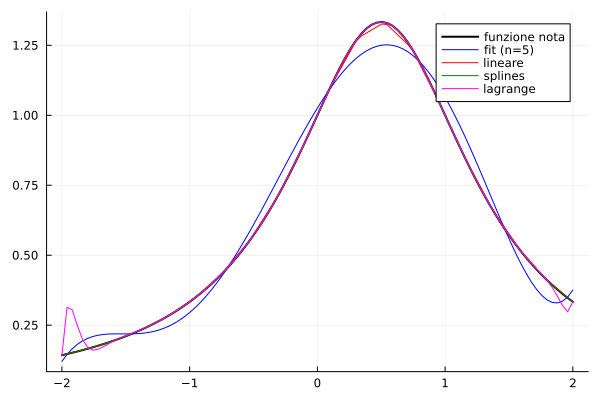

In [ ]:
using Plots
using Interpolations
using Polynomials

# 1. Setup the function and data points
f(t)=1 / (t + (1 - t).^2)
x = range(-2, 2, length=20)
y = f.(x)

# 2. Query points and exact values [cite: 115]
z = range(-2, 2, length=100)
fz = f.(z)

# 3. Calculations for different methods
# Polyfit (Least Squares) Degree 5 [cite: 117]
p1_model = fit(x, y, 5)
p1z = p1_model.(z)

# Linear Interpolation [cite: 118]
# Note: Interpolations.jl requires sorted knots
itp_linear = linear_interpolation(x, y)
p2z = itp_linear.(z)

# Spline Interpolation [cite: 118]
itp_spline = cubic_spline_interpolation(x, y)
p3z = itp_spline.(z)

# Lagrange Polynomial Interpolation [cite: 119]
# (Using the 'lagrange' function we defined in the previous step)
p4z = lagrange(x, y, z)

# 4. Error Calculation [cite: 115, 116]
errp1 = abs.(p1z .- fz)
errp2 = abs.(p2z .- fz)
errp3 = abs.(p3z .- fz)
errp4 = abs.(p4z .- fz)

# 5. Figure 1: Error Plot (Semilogy equivalent)
plt_err = plot(yscale=:log10, title="Approximation Errors", ylabel="Absolute Error")
scatter!(plt_err, errp1, mc=:blue, m=:circle, label="polyfit (n=5)")
scatter!(plt_err, errp2, mc=:red, m=:square, label="linear")
scatter!(plt_err, errp3, mc=:green, m=:diamond, label="spline")
scatter!(plt_err, errp4, mc=:magenta, m=:hexagon, label="lagrange")
display(plt_err)

# 6. Figure 2: Function Comparison [cite: 111]
plt_comp = plot(z, fz, color=:black, lw=2, label="funzione nota")
plot!(plt_comp, z, p1z, color=:blue, label="fit (n=5)")
plot!(plt_comp, z, p2z, color=:red, label="lineare")
plot!(plt_comp, z, p3z, color=:green, label="splines")
plot!(plt_comp, z, p4z, color=:magenta, label="lagrange")
display(plt_comp)